## Principles of Machine Learning Final Project
**By: Saheli Ray, Wyatt Golden, HuiDi Hu**

This notebook builds a complete tabular machine-learning workflow for predicting whether a wildlife strike caused aircraft damage. The project moves from exploratory analysis, to targeted cleaning and feature engineering, to several class-imbalance-aware models, and finally to a compact validation comparison. Throughout the project, we prioritized features and models that generalize across airports, operators, aircraft, and wildlife categories instead of memorizing sparse identifiers.


In [2]:
# All imports needed for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")

pd.options.display.max_columns = 100
        


In [3]:
# Quick environment check
%cd /home/jovyan/work
!ls

/home/jovyan/work
boosted_tree_submission.csv  HuiDis_Data_Exploration.ipynb  test.csv
extra_trees_submission.csv   neural_net_submission.csv	    train.csv
FinalProject.ipynb	     random_forest_submission.csv   train_HuiDi_1.csv
HuiDi_Model_Training.ipynb   README.md


## Data Exploration

This project predicts whether a wildlife strike caused aircraft damage. The exploration section is intentionally kept in one place so the reader can see the whole data story before the notebook moves into cleaning and modeling: the target is highly imbalanced, many raw fields are sparse or identifier-like, and several domain variables such as flight phase, animal size, speed, height, and month show useful relationships with damage.

The main modeling goal is not simply to maximize plain accuracy. Because most strikes do not report damage, a model can look accurate while ignoring the damage class. For that reason, the rest of the notebook emphasizes balanced accuracy, recall, and class-aware modeling decisions.


In [4]:
# Load dataset and look at its shape and first 5 rows
train = pd.read_csv("train.csv", low_memory=False)
print("Dataset shape:", train.shape)
train.head(5)

Dataset shape: (307178, 55)


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,RUNWAY,STATE,FAAREGION,LOCATION,OPID,OPERATOR,REG,FLT,AIRCRAFT,AMA,AMO,EMA,EMO,AC_CLASS,AC_MASS,TYPE_ENG,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,PHASE_OF_FLIGHT,HEIGHT,SPEED,DISTANCE,SKY,PRECIPITATION,BIRD_BAND_NUMBER,SPECIES_ID,SPECIES,OUT_OF_RANGE_SPECIES,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,7,PR,ASO,NaN,AAL,AMERICAN AIRLINES,N892AA,NaN,B-727-200,148,11,34.0,10.0,A,4.0,D,3.0,5.0,6.0,5.0,NaN,Approach,300.0,145.0,NaN,Some Cloud,NaN,NaN,UNKBS,Unknown bird - small,0,NO SIGN OF BIRD ON A/C.,1,0,No,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,32R,FN,FGN,NaN,FDX,FEDEX EXPRESS,N608FE,5293,MD-11,583,39,22.0,7.0,A,4.0,D,3.0,1.0,6.0,1.0,NaN,Approach,50.0,NaN,0.0,NaN,NaN,NaN,UNKBM,Unknown bird - medium,0,EVID OF STRIKE FOUND ON LOWER RT SIDE OF RADOME.,0,0,Unknown,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,35L,KY,ASO,NaN,UPS,UPS AIRLINES,N141UP,907,A-300,04A,1,34.0,46.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Approach,3500.0,240.0,8.0,NaN,NaN,NaN,UNKBL,Unknown bird - large,0,"STARTED TO SLOW DOWN FROM 250 KTS AT AROUND 4,...",0,0,No,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,25R,CA,AWP,NaN,UNK,UNKNOWN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NE120,Western gull,0,REMAINS OF 2 GULLS WERE PICKED UP OF RWY.,1,0,Unknown,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,35,HI,AWP,NaN,1AAH,ALOHA AIRLINES,NaN,NaN,B-737-200,148,13,34.0,10.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Landing Roll,0.0,135.0,0.0,Some Cloud,NaN,NaN,R1101,American barn owl,0,TIME 0824 LCL.,0,0,No,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


The first figure follows the organization from the HuiDis exploration notebook: class balance, monthly volume, bird-size damage rate, phase-of-flight damage rate, speed distribution, and the highest-missing columns. The remaining figures keep the more detailed FinalProject plots for candidate feature missingness, damage rates, month patterns, numeric distributions, and missingness-as-signal.


Training shape: (307178, 55)
Target damage rate: 0.0636


,count
INDICATED_DAMAGE,
0,287651
1,19527


Top columns by missing percentage


,missing_percent
BIRD_BAND_NUMBER,99.767887
ENG_4_POS,98.935796
ENROUTE_STATE,98.259641
PRECIPITATION,96.349999
ENG_3_POS,95.977577
LOCATION,87.232810
SPEED,69.040101
NUM_SEEN,67.890930
SKY,53.006726
FLT,52.554219


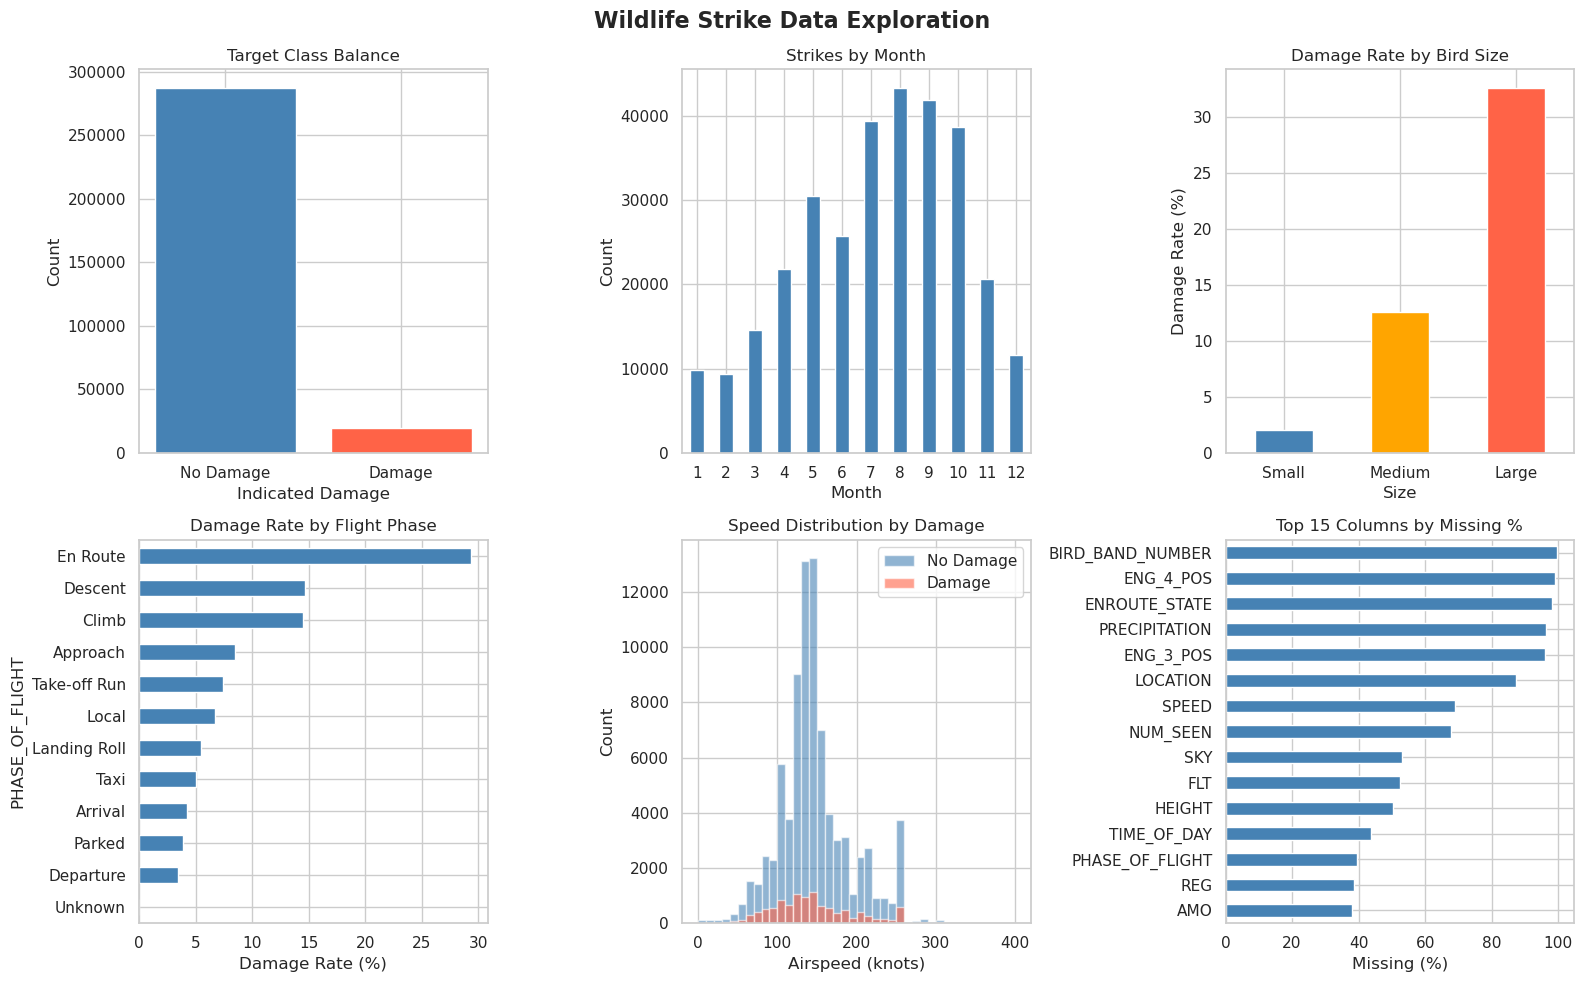

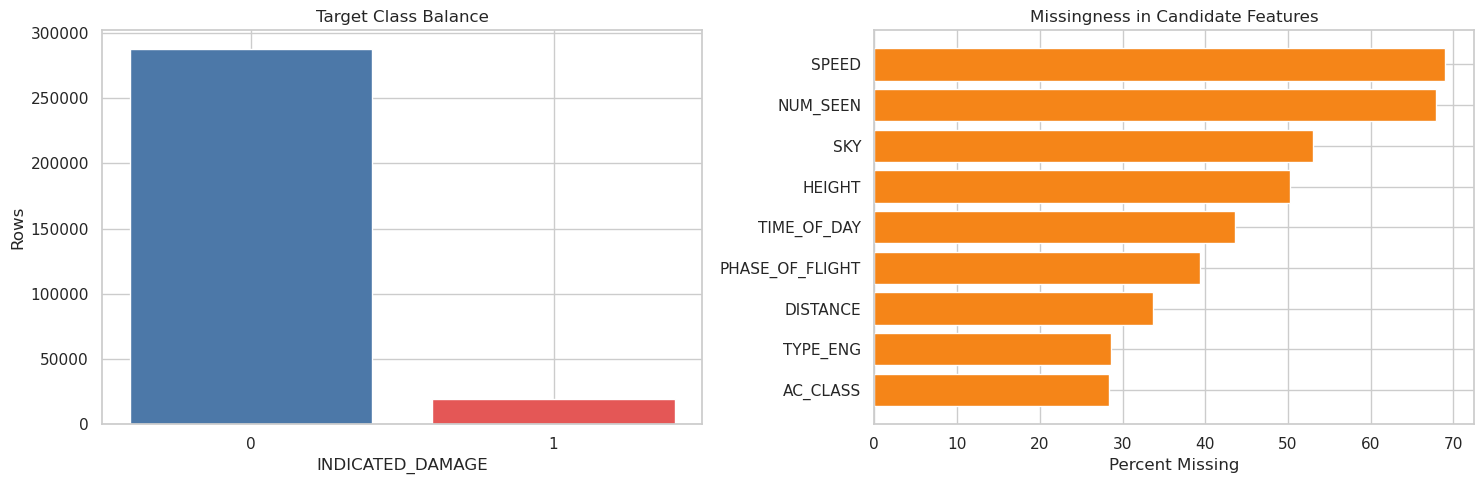

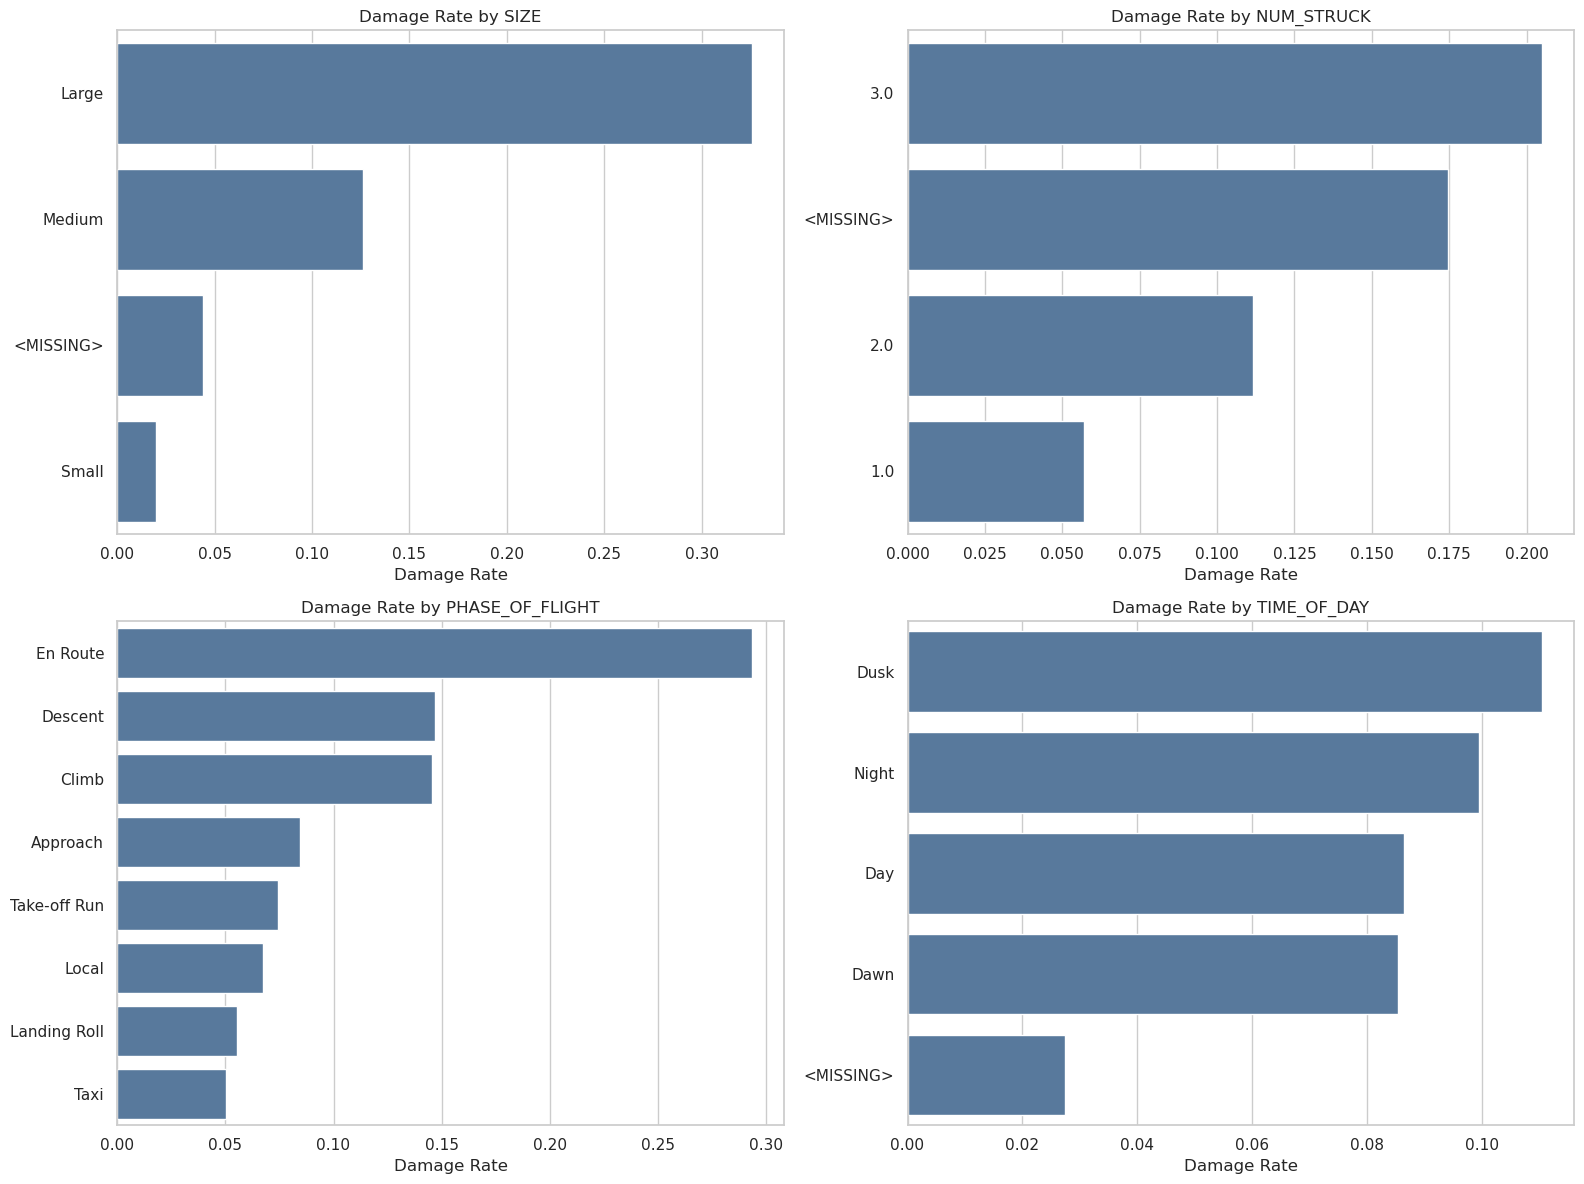

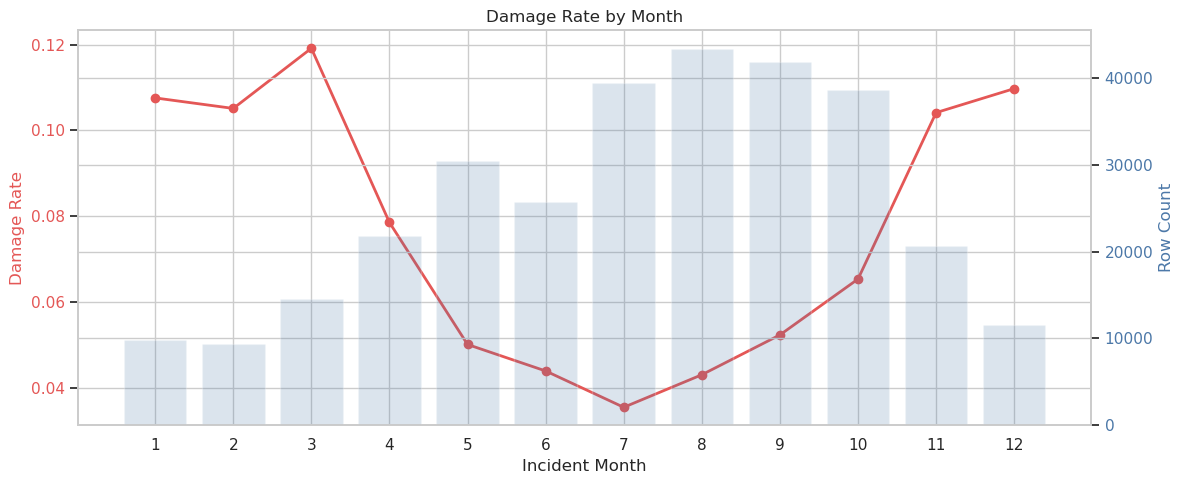

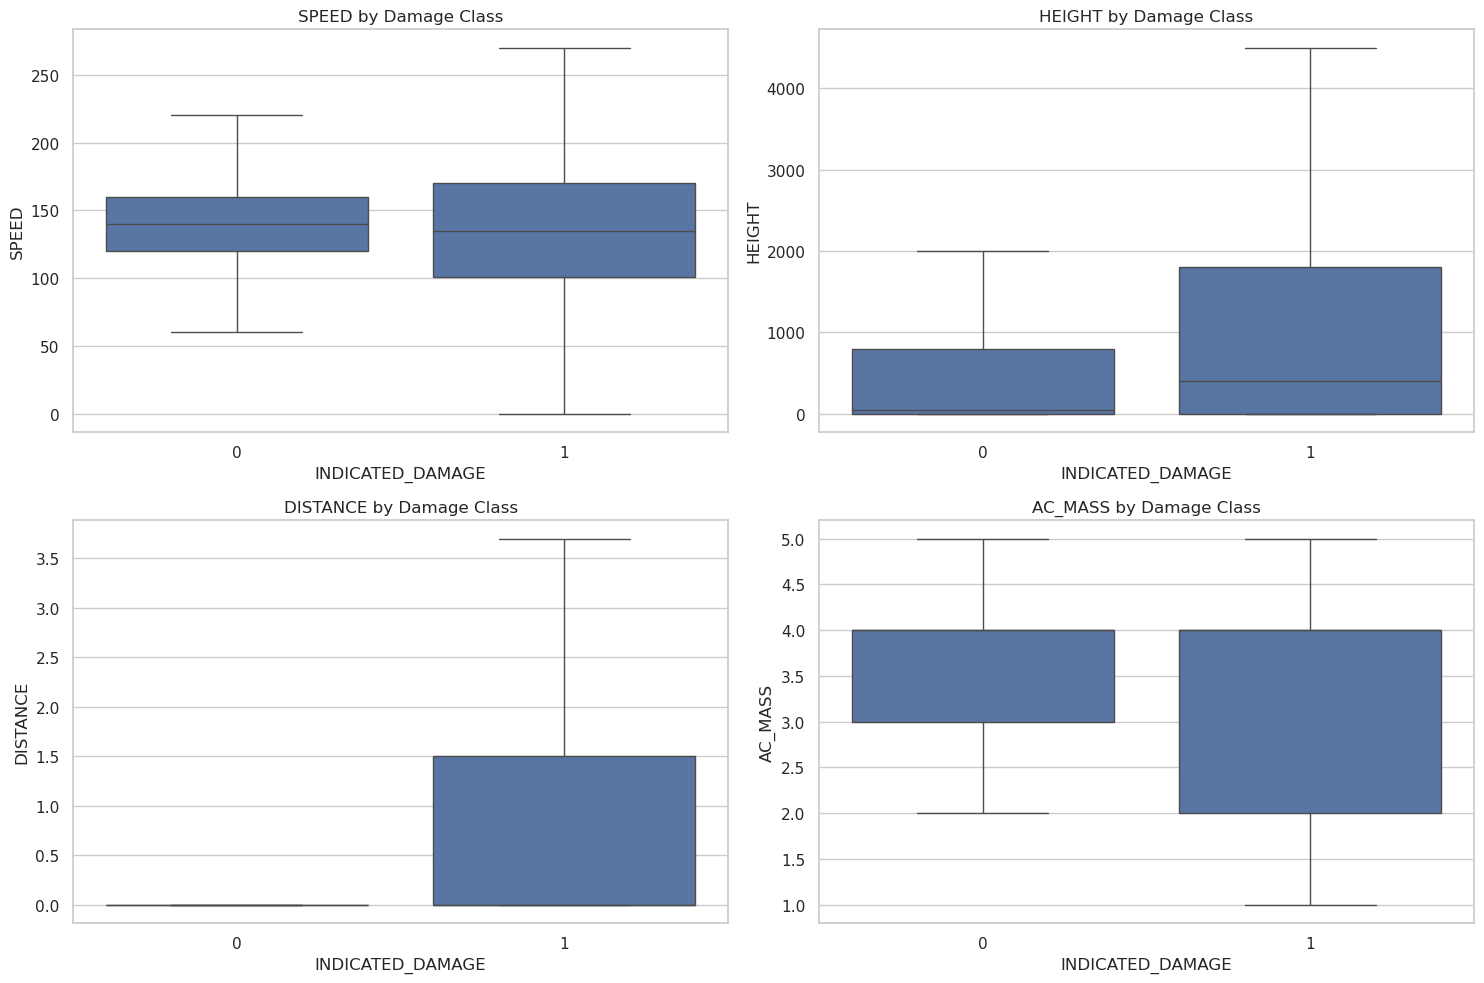

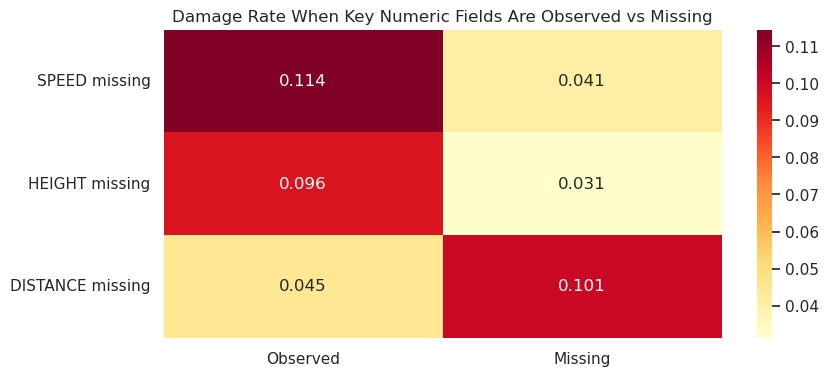

Key EDA takeaways
- The target is highly imbalanced, so balanced accuracy is the right metric to emphasize.
- Flight context variables such as PHASE_OF_FLIGHT, TIME_OF_DAY, SIZE, and decoded NUM_STRUCK show visible differences in damage rate.
- SPEED, HEIGHT, DISTANCE, and AC_MASS show different numeric distributions for damage vs no-damage rows.
- Month-to-month variation supports keeping temporal context and motivates season and cyclical month features.
- Missingness in several numeric strike-condition fields appears non-random, which helps explain the missing-indicator features.


In [5]:
# Build one organized EDA section that combines the original FinalProject plots with the HuiDis exploration plots.
sns.set_theme(style="whitegrid")

eda_columns = [
    "INDICATED_DAMAGE", "LATITUDE", "LONGITUDE", "AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS",
    "ENG_1_POS", "ENG_2_POS", "SPEED", "HEIGHT", "DISTANCE", "SIZE", "NUM_STRUCK", "NUM_SEEN",
    "PHASE_OF_FLIGHT", "TIME_OF_DAY", "SKY", "WARNED", "INCIDENT_MONTH", "FAAREGION"
]

eda = train[eda_columns].copy()
for col in ["LATITUDE", "LONGITUDE", "AC_MASS", "NUM_ENGS", "ENG_1_POS", "ENG_2_POS", "SPEED", "HEIGHT", "DISTANCE", "INCIDENT_MONTH"]:
    eda[col] = pd.to_numeric(eda[col], errors="coerce")
for col in ["NUM_SEEN", "NUM_STRUCK"]:
    eda[col] = eda[col].replace({"1": 1, "10-Feb": 2, "2-10": 2, "Feb-10": 2, "11-100": 3, "More than 100": 4})
    eda[col] = pd.to_numeric(eda[col], errors="coerce")
for col in ["AC_CLASS", "TYPE_ENG", "SIZE", "PHASE_OF_FLIGHT", "TIME_OF_DAY", "SKY", "WARNED", "FAAREGION"]:
    eda[col] = eda[col].replace(r"^\s*$", np.nan, regex=True)

print("Training shape:", train.shape)
print("Target damage rate:", round(eda["INDICATED_DAMAGE"].mean(), 4))
display(eda["INDICATED_DAMAGE"].value_counts().rename("count").to_frame())

missing_percent = (train.isna().mean() * 100).sort_values(ascending=False)
print("Top columns by missing percentage")
display(missing_percent.head(20).rename("missing_percent").to_frame())

# HuiDis-style overview figure.
def target_class_balance(ax):
    counts = eda["INDICATED_DAMAGE"].value_counts().sort_index()
    ax.bar(["No Damage", "Damage"], counts.values, color=["steelblue", "tomato"], edgecolor="white")
    ax.set_title("Target Class Balance")
    ax.set_xlabel("Indicated Damage")
    ax.set_ylabel("Count")


def strikes_by_month(ax):
    month_counts = eda.groupby("INCIDENT_MONTH").size().reindex(range(1, 13), fill_value=0)
    month_counts.plot.bar(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title("Strikes by Month")
    ax.set_xlabel("Month")
    ax.set_ylabel("Count")
    ax.set_xticklabels(range(1, 13), rotation=0)


def damage_rate_by_bird_size(ax):
    size_order = ["Small", "Medium", "Large"]
    damage_rate = eda.groupby("SIZE")["INDICATED_DAMAGE"].mean().reindex(size_order) * 100
    damage_rate.plot.bar(ax=ax, color=["steelblue", "orange", "tomato"], edgecolor="white")
    ax.set_title("Damage Rate by Bird Size")
    ax.set_xlabel("Size")
    ax.set_ylabel("Damage Rate (%)")
    ax.tick_params(axis="x", rotation=0)


def damage_rate_by_phase_of_flight(ax):
    phase_rate = eda.groupby("PHASE_OF_FLIGHT")["INDICATED_DAMAGE"].mean().sort_values() * 100
    phase_rate.plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title("Damage Rate by Flight Phase")
    ax.set_xlabel("Damage Rate (%)")


def speed_distribution_by_damage(ax):
    for label, damage_value, color in [("No Damage", 0, "steelblue"), ("Damage", 1, "tomato")]:
        values = eda.loc[eda["INDICATED_DAMAGE"] == damage_value, "SPEED"].dropna().clip(0, 400)
        ax.hist(values, bins=40, alpha=0.6, label=label, color=color)
    ax.set_title("Speed Distribution by Damage")
    ax.set_xlabel("Airspeed (knots)")
    ax.set_ylabel("Count")
    ax.legend()


def missing_values_by_column(ax):
    missing_percent.head(15).sort_values().plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title("Top 15 Columns by Missing %")
    ax.set_xlabel("Missing (%)")


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Wildlife Strike Data Exploration", fontsize=16, fontweight="bold")
target_class_balance(axes[0, 0])
strikes_by_month(axes[0, 1])
damage_rate_by_bird_size(axes[0, 2])
damage_rate_by_phase_of_flight(axes[1, 0])
speed_distribution_by_damage(axes[1, 1])
missing_values_by_column(axes[1, 2])
plt.tight_layout()
plt.show()

# Original FinalProject plot: class balance and missingness among the main candidate model fields.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
class_counts = eda["INDICATED_DAMAGE"].value_counts().sort_index()
axes[0].bar(class_counts.index.astype(str), class_counts.values, color=["#4C78A8", "#E45756"])
axes[0].set_title("Target Class Balance")
axes[0].set_xlabel("INDICATED_DAMAGE")
axes[0].set_ylabel("Rows")

missing_candidates = [
    "SPEED", "HEIGHT", "DISTANCE", "NUM_SEEN", "TIME_OF_DAY", "PHASE_OF_FLIGHT", "SKY", "TYPE_ENG", "AC_CLASS"
]
missing_rates = eda[missing_candidates].isna().mean().sort_values()
axes[1].barh(missing_rates.index, missing_rates.values * 100, color="#F58518")
axes[1].set_title("Missingness in Candidate Features")
axes[1].set_xlabel("Percent Missing")
plt.tight_layout()
plt.show()

# Original FinalProject plot: damage rate for key categorical and ordinal variables.
def damage_rate_table(column, min_count=300):
    summary = eda[[column, "INDICATED_DAMAGE"]].copy()
    summary[column] = summary[column].fillna("<MISSING>")
    summary = (
        summary.groupby(column)["INDICATED_DAMAGE"]
        .agg(["size", "mean"])
        .rename(columns={"size": "count", "mean": "damage_rate"})
        .sort_values(["damage_rate", "count"], ascending=[False, False])
    )
    return summary[summary["count"] >= min_count]

plot_columns = ["SIZE", "NUM_STRUCK", "PHASE_OF_FLIGHT", "TIME_OF_DAY"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, column in zip(axes.flat, plot_columns):
    summary = damage_rate_table(column).head(8)
    sns.barplot(data=summary.reset_index(), x="damage_rate", y=column, ax=ax, color="#4C78A8")
    ax.set_title(f"Damage Rate by {column}")
    ax.set_xlabel("Damage Rate")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

# Original FinalProject plot: month pattern to motivate season and cyclical month features.
month_damage = eda.groupby("INCIDENT_MONTH")["INDICATED_DAMAGE"].mean()
month_counts = eda.groupby("INCIDENT_MONTH").size()
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(month_damage.index, month_damage.values, marker="o", color="#E45756", linewidth=2)
ax1.set_title("Damage Rate by Month")
ax1.set_xlabel("Incident Month")
ax1.set_ylabel("Damage Rate", color="#E45756")
ax1.tick_params(axis="y", labelcolor="#E45756")
ax1.set_xticks(range(1, 13))

ax2 = ax1.twinx()
ax2.bar(month_counts.index, month_counts.values, alpha=0.2, color="#4C78A8")
ax2.set_ylabel("Row Count", color="#4C78A8")
ax2.tick_params(axis="y", labelcolor="#4C78A8")
plt.tight_layout()
plt.show()

# Original FinalProject plot: numeric signal for variables kept in modeling.
numeric_plot_columns = ["SPEED", "HEIGHT", "DISTANCE", "AC_MASS"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, column in zip(axes.flat, numeric_plot_columns):
    subset = eda[[column, "INDICATED_DAMAGE"]].dropna()
    if subset.empty:
        continue
    sampled_subset = subset.groupby("INDICATED_DAMAGE", group_keys=False).apply(
        lambda x: x.sample(min(len(x), 6000), random_state=42)
    )
    sns.boxplot(data=sampled_subset, x="INDICATED_DAMAGE", y=column, ax=ax, showfliers=False)
    ax.set_title(f"{column} by Damage Class")
plt.tight_layout()
plt.show()

# Original FinalProject plot: missingness itself as a possible signal.
missing_signal = pd.DataFrame({
    "SPEED missing": eda.groupby(eda["SPEED"].isna())["INDICATED_DAMAGE"].mean(),
    "HEIGHT missing": eda.groupby(eda["HEIGHT"].isna())["INDICATED_DAMAGE"].mean(),
    "DISTANCE missing": eda.groupby(eda["DISTANCE"].isna())["INDICATED_DAMAGE"].mean(),
}).T
missing_signal.columns = ["Observed", "Missing"]

plt.figure(figsize=(9, 4))
sns.heatmap(missing_signal, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Damage Rate When Key Numeric Fields Are Observed vs Missing")
plt.xlabel("")
plt.ylabel("")
plt.show()

print("Key EDA takeaways")
print("- The target is highly imbalanced, so balanced accuracy is the right metric to emphasize.")
print("- Flight context variables such as PHASE_OF_FLIGHT, TIME_OF_DAY, SIZE, and decoded NUM_STRUCK show visible differences in damage rate.")
print("- SPEED, HEIGHT, DISTANCE, and AC_MASS show different numeric distributions for damage vs no-damage rows.")
print("- Month-to-month variation supports keeping temporal context and motivates season and cyclical month features.")
print("- Missingness in several numeric strike-condition fields appears non-random, which helps explain the missing-indicator features.")


## Selected Features for Model Training

The raw FAA wildlife-strike data contains useful signal mixed with columns that are too sparse, too high-cardinality, or too close to free text to be reliable for this project. After re-profiling the current training data, we added back several high-signal fields that are not free text and are not row identifiers: `SPECIES_ID`, `AIRCRAFT`, `SOURCE`, `PERSON`, `REMAINS_COLLECTED`, `REMAINS_SENT`, `PRECIPITATION`, `STATE`, and `INCIDENT_YEAR`.

### Dropped outright or excluded as raw predictors
- `BIRD_BAND_NUMBER`, `ENG_3_POS`, and `ENG_4_POS`: near-total missingness.
- `INDEX_NR`, `LUPDATE`, and `TRANSFER`: identifiers or internal database fields with no useful predictive meaning.
- `REG`, `FLT`, `AIRPORT_ID`, `AIRPORT`, `OPID`, `OPERATOR`, `AMA`, `AMO`, `EMA`, and `EMO`: sparse or high-cardinality identifiers that can memorize training rows or duplicate cleaner aircraft fields.
- `REMARKS`, `COMMENTS`, `LOCATION`, and `ENROUTE_STATE`: free text with heavy missingness.
- `INCIDENT_DATE` and raw `INCIDENT_MONTH`: the exact date is too granular, and raw month is replaced by `SEASON`.
- Raw `HEIGHT` and `SPEED`: excluded as standalone predictors after creating bins, missingness flags, and interaction features.
- `SPECIES`: dropped because it duplicates `SPECIES_ID` as a longer text label.
- `ENG_1_POS`, `ENG_2_POS`, and `HAS_WING_MOUNTED_ENGINES`: the raw engine-position fields were sparse, and the simplified wing-mounted-engine flag did not add enough value to keep.

### Kept or engineered for the model
- `SPECIES_ID`: reintroduced because it has strong damage-rate separation and only hundreds, not tens of thousands, of categories.
- `AIRCRAFT`: reintroduced because aircraft model captures risk not fully represented by mass and engine count; rare aircraft are grouped by the one-hot encoder.
- `SOURCE`, `PERSON`, `REMAINS_COLLECTED`, and `REMAINS_SENT`: reporting and evidence fields that are strongly associated with damage. They may partly reflect post-event reporting behavior, so they should be interpreted carefully, but they are present in both train and test data and can improve competition performance.
- `STATE`, `FAAREGION`, `LATITUDE`, and `LONGITUDE`: geographic signal at multiple levels.
- `INCIDENT_YEAR` and `SEASON`: coarse temporal context without using exact dates.
- `PRECIPITATION`, `SKY`, `TIME_OF_DAY`, `WARNED`, and `PHASE_OF_FLIGHT`: environmental and flight-context variables.
- `SIZE`, `NUM_STRUCK`, and `NUM_SEEN`: biological size and encounter size.
- `SPEED_AC_MASS`, `HEIGHT_SPEED`, `HEIGHT_BAND`, `SPEED_BAND`, `DISTANCE_BAND`, `IS_GROUND_STRIKE`, `MULTI_STRIKE`, and `IS_LARGE_AIRCRAFT`: compact domain features for impact severity and strike context.
- `SPEED_MISSING`, `HEIGHT_MISSING`, and `DISTANCE_MISSING`: missingness indicators retained because the EDA suggested missingness itself is informative.

### Missing data strategy
- Moderate-missing categorical variables are filled with `Unknown` so missingness can remain informative.
- `HEIGHT` and `SPEED` are median-imputed within `PHASE_OF_FLIGHT` before interaction and binned features are created; `DISTANCE` is median-imputed globally.
- Rows with missing `INDICATED_DAMAGE` are dropped from training because they cannot be used as labeled examples.


In [6]:
# Raw columns that are allowed into cleaning. Some are used only to build engineered features.
selected_columns = [
    "LATITUDE", "LONGITUDE", "STATE", "FAAREGION",
    "AC_CLASS", "AC_MASS", "TYPE_ENG", "NUM_ENGS", "AIRCRAFT",
    "SPEED", "HEIGHT", "DISTANCE",
    "SIZE", "SPECIES_ID", "NUM_STRUCK", "NUM_SEEN",
    "PHASE_OF_FLIGHT", "TIME_OF_DAY", "SKY", "PRECIPITATION", "WARNED",
    "INCIDENT_MONTH", "INCIDENT_YEAR",
    "SOURCE", "PERSON", "REMAINS_COLLECTED", "REMAINS_SENT",
    "INDICATED_DAMAGE",  # Target variable
]

columns_excluded_as_raw_predictors = [
    "BIRD_BAND_NUMBER", "INDEX_NR", "REG", "FLT", "REMARKS", "COMMENTS", "LOCATION",
    "ENROUTE_STATE", "LUPDATE", "TRANSFER", "INCIDENT_DATE", "INCIDENT_MONTH", "AIRPORT_ID", "AIRPORT",
    "OPID", "OPERATOR", "AMA", "AMO", "EMA", "EMO", "SPECIES", "ENG_1_POS", "ENG_2_POS",
    "ENG_3_POS", "ENG_4_POS", "HEIGHT", "SPEED", "HAS_WING_MOUNTED_ENGINES",
]

raw_numeric_features = [
    "LATITUDE", "LONGITUDE", "AC_MASS", "NUM_ENGS", "DISTANCE", "INCIDENT_YEAR", "NUM_STRUCK", "NUM_SEEN",
]
engineered_numeric_features = [
    "SPEED_AC_MASS", "HEIGHT_SPEED", "IS_GROUND_STRIKE", "MULTI_STRIKE", "IS_LARGE_AIRCRAFT",
    "SPEED_MISSING", "HEIGHT_MISSING", "DISTANCE_MISSING",
]
numeric_features = raw_numeric_features + engineered_numeric_features
categorical_features = [
    "AC_CLASS", "TYPE_ENG", "AIRCRAFT", "SIZE", "SPECIES_ID", "PHASE_OF_FLIGHT", "TIME_OF_DAY",
    "SKY", "PRECIPITATION", "WARNED", "STATE", "FAAREGION", "SEASON", "HEIGHT_BAND", "SPEED_BAND",
    "DISTANCE_BAND", "SOURCE", "PERSON", "REMAINS_COLLECTED", "REMAINS_SENT",
]
raw_feature_columns = [col for col in selected_columns if col != "INDICATED_DAMAGE"]
feature_columns = numeric_features + categorical_features

encounter_size_map = {
    "1": 1,
    "10-Feb": 2,
    "2-10": 2,
    "Feb-10": 2,
    "11-100": 3,
    "More than 100": 4,
}

phase_numeric_imputation_values = {}


def month_to_season(month):
    if pd.isna(month):
        return "Unknown"
    month = int(month)
    if month in [1, 2, 3]:
        return "Winter"
    if month in [4, 5, 6]:
        return "Spring"
    if month in [7, 8, 9]:
        return "Summer"
    if month in [10, 11, 12]:
        return "Fall"
    return "Unknown"


def bin_height(height):
    if pd.isna(height):
        return "Unknown"
    if height == 0:
        return "Ground"
    if height <= 100:
        return "Low"
    if height <= 1000:
        return "Pattern"
    if height <= 5000:
        return "Climb/Descent"
    return "High"


def bin_speed(speed):
    if pd.isna(speed):
        return "Unknown"
    if speed <= 80:
        return "Slow"
    if speed <= 160:
        return "Moderate"
    if speed <= 250:
        return "Fast"
    return "Very Fast"


def bin_distance(distance):
    if pd.isna(distance):
        return "Unknown"
    if distance == 0:
        return "At Airport"
    if distance <= 5:
        return "Near Airport"
    if distance <= 20:
        return "Terminal Area"
    return "Far"


def add_domain_imputations(cleaned, fit=False):
    global phase_numeric_imputation_values

    if fit:
        phase_numeric_imputation_values = {
            "HEIGHT": {
                "group_medians": cleaned.groupby("PHASE_OF_FLIGHT")["HEIGHT"].median(),
                "global_median": cleaned["HEIGHT"].median(),
            },
            "SPEED": {
                "group_medians": cleaned.groupby("PHASE_OF_FLIGHT")["SPEED"].median(),
                "global_median": cleaned["SPEED"].median(),
            },
            "DISTANCE": {
                "global_median": cleaned["DISTANCE"].median(),
            },
        }

    for col in ["HEIGHT", "SPEED"]:
        values = phase_numeric_imputation_values.get(col, {})
        group_medians = values.get("group_medians", pd.Series(dtype=float))
        global_median = values.get("global_median", cleaned[col].median())
        phase_fill_values = cleaned["PHASE_OF_FLIGHT"].map(group_medians)
        cleaned[col] = cleaned[col].fillna(phase_fill_values).fillna(global_median)

    distance_median = phase_numeric_imputation_values.get("DISTANCE", {}).get("global_median", cleaned["DISTANCE"].median())
    cleaned["DISTANCE"] = cleaned["DISTANCE"].fillna(distance_median)
    return cleaned


def clean_feature_frame(df, columns, fit_imputers=False):
    # Copy only the columns we need so later cleaning does not affect the original dataframe.
    cleaned = df[columns].copy()

    # Convert coordinates and numeric strike/aircraft fields to numbers. Any invalid value becomes NaN.
    for col in ["LATITUDE", "LONGITUDE", "AC_MASS", "NUM_ENGS", "SPEED", "HEIGHT", "DISTANCE", "INCIDENT_MONTH", "INCIDENT_YEAR"]:
        if col in cleaned.columns:
            cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    # Excel-misread encounter ranges become ordinal numeric values.
    for col in ["NUM_SEEN", "NUM_STRUCK"]:
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].replace(encounter_size_map)
            cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    # Treat blank categorical values as missing and preserve missingness as its own category.
    for col in categorical_features:
        if col in cleaned.columns:
            cleaned[col] = cleaned[col].replace(r"^\s*$", np.nan, regex=True).fillna("Unknown").astype(str).str.strip()

    # Missingness appears informative for several sparse strike-condition fields.
    for col in ["SPEED", "HEIGHT", "DISTANCE"]:
        cleaned[f"{col}_MISSING"] = cleaned[col].isna().astype(int) if col in cleaned.columns else 1

    # Phase-aware numeric imputation reflects that height/speed mean different things in different flight phases.
    cleaned = add_domain_imputations(cleaned, fit=fit_imputers)

    # Domain feature engineering. Raw HEIGHT, SPEED, and INCIDENT_MONTH are not returned as final predictors.
    cleaned["SPEED_AC_MASS"] = cleaned["SPEED"] * cleaned["AC_MASS"]
    cleaned["HEIGHT_SPEED"] = cleaned["HEIGHT"] * cleaned["SPEED"]
    cleaned["SEASON"] = cleaned["INCIDENT_MONTH"].apply(month_to_season)
    cleaned["HEIGHT_BAND"] = cleaned["HEIGHT"].apply(bin_height)
    cleaned["SPEED_BAND"] = cleaned["SPEED"].apply(bin_speed)
    cleaned["DISTANCE_BAND"] = cleaned["DISTANCE"].apply(bin_distance)
    cleaned["IS_GROUND_STRIKE"] = (cleaned["HEIGHT"] == 0).astype(int)
    cleaned["MULTI_STRIKE"] = (cleaned["NUM_STRUCK"] > 1).astype(int)
    cleaned["IS_LARGE_AIRCRAFT"] = (cleaned["AC_MASS"] >= 4).astype(int)

    return cleaned


def prepare_training_data(df):
    # Clean the training columns first so missing and malformed values are standardized.
    cleaned = clean_feature_frame(df, selected_columns, fit_imputers=True)

    # Drop rows only when the target is missing. Feature NaNs will be handled in the model pipeline.
    cleaned = cleaned.dropna(subset=["INDICATED_DAMAGE"]).copy()
    return cleaned[feature_columns + ["INDICATED_DAMAGE"]]


def prepare_prediction_data(df):
    # Clean the test features but keep rows with missing feature values for the imputer to fill.
    cleaned = clean_feature_frame(df, raw_feature_columns, fit_imputers=False)
    return cleaned[feature_columns]


# Build the cleaned training dataset that will be used for splitting and fitting.
train_clean = prepare_training_data(train)

# Take a quick look at the cleaned training data.
print("Excluded raw predictor columns:", columns_excluded_as_raw_predictors)
print(train_clean.shape)
print(train_clean.head())
print(train_clean.dtypes)


Excluded raw predictor columns: ['BIRD_BAND_NUMBER', 'INDEX_NR', 'REG', 'FLT', 'REMARKS', 'COMMENTS', 'LOCATION', 'ENROUTE_STATE', 'LUPDATE', 'TRANSFER', 'INCIDENT_DATE', 'INCIDENT_MONTH', 'AIRPORT_ID', 'AIRPORT', 'OPID', 'OPERATOR', 'AMA', 'AMO', 'EMA', 'EMO', 'SPECIES', 'ENG_1_POS', 'ENG_2_POS', 'ENG_3_POS', 'ENG_4_POS', 'HEIGHT', 'SPEED', 'HAS_WING_MOUNTED_ENGINES']
(307178, 37)
    LATITUDE   LONGITUDE  AC_MASS  NUM_ENGS  DISTANCE  INCIDENT_YEAR  \
0  18.439420  -66.001830      4.0       3.0       0.0           1993   
1   2.745578  101.709917      4.0       3.0       0.0           2010   
2  38.174390  -85.736000      4.0       2.0       8.0           2012   
3  33.942540 -118.408070      NaN       NaN       0.0           2002   
4  21.975980 -159.338960      4.0       2.0       0.0           1997   

   NUM_STRUCK  NUM_SEEN  SPEED_AC_MASS  HEIGHT_SPEED  IS_GROUND_STRIKE  \
0         2.0       2.0          580.0       43500.0                 0   
1         1.0       NaN          5

## Feature Engineering Summary

The final feature set reflects several rounds of trial and simplification. We kept transformations that were interpretable and helped represent the domain without exploding dimensionality: ordinal encounter-size decoding, latitude/longitude casting, phase-aware imputation for `HEIGHT` and `SPEED`, global imputation for `DISTANCE`, `SEASON`, `IS_GROUND_STRIKE`, `MULTI_STRIKE`, `IS_LARGE_AIRCRAFT`, `SPEED_AC_MASS`, `HEIGHT_SPEED`, `HEIGHT_BAND`, `SPEED_BAND`, and `DISTANCE_BAND`.

After re-checking the raw data, we also restored a few high-signal fields that had been too aggressively removed. `SPECIES_ID` and `AIRCRAFT` have manageable cardinality and strong target separation. `SOURCE`, `PERSON`, and remains fields are reporting/evidence variables, so they should be interpreted carefully, but they are present in the competition data and can materially improve balanced accuracy. `STATE`, `PRECIPITATION`, and `INCIDENT_YEAR` add geographic, weather, and time-period context that the previous feature set was missing.

Some earlier ideas were still removed because they did not improve validation performance or made the feature space noisier. Raw free text, exact airport identifiers, exact dates, tail numbers, and raw operator IDs remain excluded because they are either too sparse, too messy, or too likely to memorize rows. Raw `HEIGHT` and `SPEED` are no longer standalone predictors because bins and interactions capture the useful impact-severity signal more directly.


## Model Training and Comparison

The models below were chosen for an imbalanced tabular classification problem. Decision trees and tree ensembles handle mixed numeric/categorical one-hot features well, are not strongly affected by feature scaling, and can model non-linear relationships such as high-speed strikes on heavier aircraft. Random Forest and Extra Trees also reduce the instability of a single tree by averaging many trees, which helps in a high-dimensional encoded dataset.

We intentionally avoided models that rely heavily on proximity or distance in the raw feature space, such as k-nearest neighbors, because one-hot encoded categorical data can make distance less meaningful and high dimensionality can weaken neighborhood-based methods. The chosen models either use class weighting, resampling, threshold tuning, or tree splits that are more appropriate for the imbalance and feature mix in this dataset.

We tuned the single decision tree first to see how much hyperparameter search helped. The tuned tree did not improve much over the simpler tree behavior, so we decided not to tune Random Forest or Extra Trees. Those searches were computationally expensive enough to crash the kernel, and the decision-tree result suggested that broad tuning was unlikely to be worth the runtime cost. Instead, the forest models use reasonable fixed settings with class weighting. The boosted tree reuses the tuned decision-tree hyperparameters as its base estimator instead of running a second search. The neural network uses oversampling and threshold tuning because its default behavior can produce high accuracy but poor balanced accuracy on imbalanced data.


## Tuned Decision Tree

The first model is a decision tree tuned with randomized search over depth, split size, leaf size, and criterion. The search optimizes balanced accuracy because the target is imbalanced and plain accuracy can hide poor minority-class performance. After tuning, the improvement was small, which guided our later decision to keep the more expensive forest ensembles fixed rather than spending much more compute on searches that were crashing the kernel.
        


In [7]:
# Split the cleaned data into features and target
X = train_clean.drop(columns="INDICATED_DAMAGE")
y = train_clean["INDICATED_DAMAGE"]

# Hold out part of the training data for evaluation.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

model_results = []


def find_best_threshold(y_true, probabilities):
    threshold_scores = []
    for threshold in np.linspace(0.01, 0.99, 197):
        predictions = (probabilities >= threshold).astype(int)
        threshold_scores.append((balanced_accuracy_score(y_true, predictions), threshold))
    return max(threshold_scores, key=lambda item: item[0])


def evaluate_model(model_name, y_true, predictions, probabilities, threshold=None):
    metrics = {
        "Model": model_name,
        "Threshold": threshold if threshold is not None else 0.5,
        "Accuracy": accuracy_score(y_true, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1 Score": f1_score(y_true, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, probabilities),
    }
    model_results.append(metrics)

    print(f"{model_name} Evaluation Results")
    if threshold is not None:
        print(f"{'Threshold:':<20}{threshold:.3f}")
    for metric_name in ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]:
        print(f"{metric_name + ':':<20}{metrics[metric_name]:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, predictions))
    print("\nClassification Report:")
    print(classification_report(y_true, predictions, zero_division=0))
    return metrics


# Numeric values have already received domain-aware imputation where requested; this catches any remaining NaNs.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

# Preserve missing categorical values as Unknown, then one-hot encode them.
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=25)),
    ]
)

# Apply the numeric and categorical preprocessing so train, validation, and test are handled the same way.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Build the decision tree pipeline so preprocessing and prediction stay connected.
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(class_weight="balanced", random_state=42)),
    ]
)

# Tune the decision tree hyperparameters using balanced accuracy.
dt_param_distributions = {
    "classifier__max_depth": [6, 8, 10, 12, 14, 16, 20, None],
    "classifier__min_samples_split": [2, 10, 25, 50, 100, 250],
    "classifier__min_samples_leaf": [5, 10, 25, 50, 100],
    "classifier__criterion": ["gini", "entropy", "log_loss"],
}

dt_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
decision_tree_search = RandomizedSearchCV(
    estimator=decision_tree_model,
    param_distributions=dt_param_distributions,
    n_iter=20,
    scoring="balanced_accuracy",
    cv=dt_cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

# Fit the tuned decision tree on the training split.
decision_tree_search.fit(X_train, y_train)
decision_tree_model = decision_tree_search.best_estimator_
print("Best Decision Tree Parameters:", decision_tree_search.best_params_)
print(f"Best CV Balanced Accuracy: {decision_tree_search.best_score_:.4f}\n")

# Predict probabilities on the validation split and tune the threshold for balanced accuracy.
dt_val_probabilities = decision_tree_model.predict_proba(X_val)[:, 1]
dt_best_balanced_accuracy, dt_threshold = find_best_threshold(y_val, dt_val_probabilities)
dt_val_predictions = (dt_val_probabilities >= dt_threshold).astype(int)
evaluate_model("Tuned Decision Tree", y_val, dt_val_predictions, dt_val_probabilities, threshold=dt_threshold)

# Retrain the tuned tree on all cleaned training rows before making final test predictions.
decision_tree_model.fit(X, y)

# Load the test data and keep every row so the model predicts on the full submission set.
test_data = pd.read_csv("test.csv", low_memory=False)
X_test = prepare_prediction_data(test_data)

# Generate thresholded predictions for every test row after the pipeline fills missing values.
dt_test_probabilities = decision_tree_model.predict_proba(X_test)[:, 1]
dt_test_predictions = (dt_test_probabilities >= dt_threshold).astype(int)

# Build and save the decision tree submission file.
decision_tree_submission = test_data[["INDEX_NR"]].copy()
decision_tree_submission["INDICATED_DAMAGE"] = dt_test_predictions
decision_tree_submission.to_csv("decision_tree_submission.csv", index=False)
print("Saved submission file to decision_tree_submission.csv")
        


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Decision Tree Parameters: {'classifier__min_samples_split': 25, 'classifier__min_samples_leaf': 100, 'classifier__max_depth': 10, 'classifier__criterion': 'gini'}
Best CV Balanced Accuracy: 0.8011

Tuned Decision Tree Evaluation Results
Threshold:          0.395
Accuracy:           0.7664
Balanced Accuracy:  0.8057
Precision:          0.1944
Recall:             0.8507
F1 Score:           0.3165
ROC AUC:            0.8891

Confusion Matrix:
[[43765 13766]
 [  583  3322]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.76      0.86     57531
           1       0.19      0.85      0.32      3905

    accuracy                           0.77     61436
   macro avg       0.59      0.81      0.59     61436
weighted avg       0.94      0.77      0.82     61436

Saved submission file to decision_tree_submission.csv


## Random Forest

Random Forest averages many decision trees to reduce variance while keeping the advantages of tree-based modeling on one-hot encoded tabular data. We use `class_weight="balanced_subsample"` so each tree pays more attention to the minority damage class.

We intentionally do not run hyperparameter tuning here. The Random Forest search was causing kernel crashes, and the tuned decision tree did not show enough improvement to justify a much more expensive forest search. The fixed settings below are a conservative compromise: enough trees for stability, bounded depth and leaf size to reduce overfitting, and limited parallelism to keep memory use under control.


In [8]:
# Build the random forest pipeline using fixed settings to avoid expensive searches that crash the kernel.
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=250,
                max_depth=18,
                min_samples_leaf=8,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=2,
            ),
        ),
    ]
)

# Fit the random forest on the training split.
random_forest_model.fit(X_train, y_train)

# Predict probabilities on the validation split and tune the threshold for balanced accuracy.
rf_val_probabilities = random_forest_model.predict_proba(X_val)[:, 1]
rf_best_balanced_accuracy, rf_threshold = find_best_threshold(y_val, rf_val_probabilities)
rf_val_predictions = (rf_val_probabilities >= rf_threshold).astype(int)
evaluate_model("Random Forest", y_val, rf_val_predictions, rf_val_probabilities, threshold=rf_threshold)

# Retrain the random forest on all cleaned training rows.
random_forest_model.fit(X, y)

# Generate thresholded predictions for every test row using the same imputation pipeline.
rf_test_probabilities = random_forest_model.predict_proba(X_test)[:, 1]
rf_test_predictions = (rf_test_probabilities >= rf_threshold).astype(int)

# Build and save the random forest submission file.
random_forest_submission = test_data[["INDEX_NR"]].copy()
random_forest_submission["INDICATED_DAMAGE"] = rf_test_predictions
random_forest_submission.to_csv("random_forest_submission.csv", index=False)
print("Saved submission file to random_forest_submission.csv")
        


Random Forest Evaluation Results
Threshold:          0.480
Accuracy:           0.8144
Balanced Accuracy:  0.8165
Precision:          0.2301
Recall:             0.8190
F1 Score:           0.3593
ROC AUC:            0.9035

Confusion Matrix:
[[46833 10698]
 [  707  3198]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89     57531
           1       0.23      0.82      0.36      3905

    accuracy                           0.81     61436
   macro avg       0.61      0.82      0.63     61436
weighted avg       0.94      0.81      0.86     61436

Saved submission file to random_forest_submission.csv


## Extremely Randomized Forest

An extremely randomized forest (`ExtraTreesClassifier`) is another tree ensemble. It adds more randomness than a standard random forest when choosing split thresholds, which can reduce variance and sometimes improves generalization on noisy tabular data.

Like Random Forest, this model is not tuned in this notebook. Extra Trees is already computationally heavy on a large one-hot encoded dataset, and the earlier decision-tree tuning did not produce enough improvement to make an expensive Extra Trees search worthwhile. We keep fixed, class-weighted settings so the notebook can run reliably.


In [10]:
# Build an extremely randomized forest pipeline using fixed settings for reliability.
extra_trees_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            ExtraTreesClassifier(
                n_estimators=250,
                max_depth=18,
                min_samples_leaf=8,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=2,
            ),
        ),
    ]
)

# Fit the Extra Trees model on the training split.
extra_trees_model.fit(X_train, y_train)

# Predict probabilities on the validation split and tune the threshold for balanced accuracy.
et_val_probabilities = extra_trees_model.predict_proba(X_val)[:, 1]
et_best_balanced_accuracy, et_threshold = find_best_threshold(y_val, et_val_probabilities)
et_val_predictions = (et_val_probabilities >= et_threshold).astype(int)
evaluate_model("Extra Trees", y_val, et_val_predictions, et_val_probabilities, threshold=et_threshold)

# Retrain the Extra Trees model on all cleaned training rows.
extra_trees_model.fit(X, y)

# Generate thresholded predictions for every test row using the same preprocessing pipeline.
et_test_probabilities = extra_trees_model.predict_proba(X_test)[:, 1]
et_test_predictions = (et_test_probabilities >= et_threshold).astype(int)

# Build and save the Extra Trees submission file.
extra_trees_submission = test_data[["INDEX_NR"]].copy()
extra_trees_submission["INDICATED_DAMAGE"] = et_test_predictions
extra_trees_submission.to_csv("extra_trees_submission.csv", index=False)
print("Saved submission file to extra_trees_submission.csv")


KeyboardInterrupt: 

## Boosted Tree With Tuned Decision-Tree Base

AdaBoost fits decision trees sequentially so later trees focus more on examples earlier trees handled poorly. We included it because it gives a different tree-based comparison from bagging-style ensembles like Random Forest and Extra Trees.

Instead of tuning AdaBoost separately, this section reuses the best hyperparameters found for the decision tree above as the base estimator. That keeps the notebook lighter and avoids another expensive randomized search while still giving the boosted model a tuned tree structure to start from.


In [ ]:
# Reuse the best hyperparameters from the tuned decision tree as AdaBoost's base estimator.
best_tree_classifier = decision_tree_model.named_steps["classifier"]
best_tree_params = best_tree_classifier.get_params()

boosted_base_tree = DecisionTreeClassifier(
    criterion=best_tree_params["criterion"],
    max_depth=best_tree_params["max_depth"],
    min_samples_split=best_tree_params["min_samples_split"],
    min_samples_leaf=best_tree_params["min_samples_leaf"],
    class_weight=best_tree_params["class_weight"],
    random_state=42,
)

print("Boosted tree base estimator uses tuned decision tree parameters:")
print({
    "criterion": boosted_base_tree.criterion,
    "max_depth": boosted_base_tree.max_depth,
    "min_samples_split": boosted_base_tree.min_samples_split,
    "min_samples_leaf": boosted_base_tree.min_samples_leaf,
    "class_weight": boosted_base_tree.class_weight,
})

# Build a boosted tree pipeline using the tuned decision tree as the base estimator.
boosted_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            AdaBoostClassifier(
                estimator=boosted_base_tree,
                n_estimators=250,
                learning_rate=0.1,
                random_state=42,
            ),
        ),
    ]
)

# Fit the boosted tree model on the training split.
boosted_tree_model.fit(X_train, y_train)

# Predict probabilities on the validation split and tune the threshold for balanced accuracy.
bt_val_probabilities = boosted_tree_model.predict_proba(X_val)[:, 1]
bt_best_balanced_accuracy, bt_threshold = find_best_threshold(y_val, bt_val_probabilities)
bt_val_predictions = (bt_val_probabilities >= bt_threshold).astype(int)
evaluate_model("Boosted Tree", y_val, bt_val_predictions, bt_val_probabilities, threshold=bt_threshold)

# Retrain the boosted tree model on all cleaned training rows.
boosted_tree_model.fit(X, y)

# Generate thresholded predictions for every test row using the same preprocessing pipeline.
bt_test_probabilities = boosted_tree_model.predict_proba(X_test)[:, 1]
bt_test_predictions = (bt_test_probabilities >= bt_threshold).astype(int)

# Build and save the boosted-tree submission file.
boosted_tree_submission = test_data[["INDEX_NR"]].copy()
boosted_tree_submission["INDICATED_DAMAGE"] = bt_test_predictions
boosted_tree_submission.to_csv("boosted_tree_submission.csv", index=False)
print("Saved submission file to boosted_tree_submission.csv")


## Imbalance-Aware Neural Network

The neural network is included as a non-tree comparison, but neural nets can be especially misleading on this dataset: they may achieve high accuracy by mostly predicting the majority no-damage class. To address that, this section oversamples the minority class before training and tunes the decision threshold on the validation split to maximize balanced accuracy instead of defaulting to a 0.50 cutoff.

The neural network uses scaled numeric inputs and dense one-hot encoded categoricals because gradient-based models are sensitive to feature scale. To keep memory under control, it excludes the highest-cardinality categorical fields (`AIRCRAFT` and `SPECIES_ID`) that the sparse tree pipelines can handle more comfortably. Even with these adjustments, it is mainly a comparison point; the tree-based models are usually a more natural fit for this kind of mixed, tabular, imbalanced data.


In [ ]:
# Build a preprocessing pipeline tailored for a neural network.
neural_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

neural_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=100, sparse_output=False)),
    ]
)

# Keep the neural-network design smaller than the tree models because dense one-hot matrices can get large.
neural_categorical_features = [
    col for col in categorical_features if col not in ["AIRCRAFT", "SPECIES_ID"]
]

neural_preprocessor = ColumnTransformer(
    transformers=[
        ("num", neural_numeric_transformer, numeric_features),
        ("cat", neural_categorical_transformer, neural_categorical_features),
    ],
    sparse_threshold=0,
)


def make_balanced_training_frame(X_frame, y_series, random_state=42):
    training_frame = X_frame.copy()
    training_frame["_target"] = y_series.values
    target_counts = training_frame["_target"].value_counts()
    target_size = target_counts.max()

    balanced_parts = []
    for target_value, group in training_frame.groupby("_target"):
        balanced_parts.append(
            group.sample(
                n=target_size,
                replace=len(group) < target_size,
                random_state=random_state,
            )
        )

    balanced = pd.concat(balanced_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced.drop(columns="_target"), balanced["_target"]


# Build a small feed-forward neural network for comparison.
neural_net_model = Pipeline(
    steps=[
        ("preprocessor", neural_preprocessor),
        (
            "classifier",
            MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.0005,
                learning_rate_init=0.001,
                max_iter=300,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=42,
            ),
        ),
    ]
)

# Oversample the minority class before fitting so the neural network does not learn to predict mostly no-damage.
X_train_nn_balanced, y_train_nn_balanced = make_balanced_training_frame(X_train, y_train, random_state=42)
neural_net_model.fit(X_train_nn_balanced, y_train_nn_balanced)

# Tune the prediction threshold on validation probabilities to maximize balanced accuracy.
nn_val_probabilities = neural_net_model.predict_proba(X_val)[:, 1]
best_nn_balanced_accuracy, best_nn_threshold = find_best_threshold(y_val, nn_val_probabilities)
nn_val_predictions = (nn_val_probabilities >= best_nn_threshold).astype(int)
print(f"Best Neural Network Threshold: {best_nn_threshold:.3f}")
print(f"Best Threshold Balanced Accuracy: {best_nn_balanced_accuracy:.4f}\n")
evaluate_model("Balanced Neural Network", y_val, nn_val_predictions, nn_val_probabilities, threshold=best_nn_threshold)

# Retrain the neural network on a balanced version of all cleaned training rows.
X_nn_balanced, y_nn_balanced = make_balanced_training_frame(X, y, random_state=42)
neural_net_model.fit(X_nn_balanced, y_nn_balanced)

# Generate thresholded predictions for every test row using the same preprocessing pipeline.
nn_test_probabilities = neural_net_model.predict_proba(X_test)[:, 1]
nn_test_predictions = (nn_test_probabilities >= best_nn_threshold).astype(int)

# Build and save the neural-network submission file.
neural_net_submission = test_data[["INDEX_NR"]].copy()
neural_net_submission["INDICATED_DAMAGE"] = nn_test_predictions
neural_net_submission.to_csv("neural_net_submission.csv", index=False)
print("Saved submission file to neural_net_submission.csv")


## Final Model Comparison

This compact table compares every validation run using the same held-out split, with balanced accuracy emphasized because it accounts for the strong class imbalance in `INDICATED_DAMAGE`. Accuracy is still shown, but balanced accuracy, recall, and F1 are more useful for judging whether the model is finding both damage and no-damage cases.


In [ ]:
# Compare all validation metrics collected from the model sections above.
comparison_columns = ["Model", "Threshold", "Balanced Accuracy", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
model_comparison = pd.DataFrame(model_results)[comparison_columns].sort_values(
    by="Balanced Accuracy",
    ascending=False,
).reset_index(drop=True)

display(model_comparison.style.format({
    "Threshold": "{:.3f}",
    "Balanced Accuracy": "{:.4f}",
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC AUC": "{:.4f}",
}))

plt.figure(figsize=(10, 5))
sns.barplot(data=model_comparison, x="Balanced Accuracy", y="Model", color="#4C78A8")
plt.title("Validation Balanced Accuracy by Model")
plt.xlim(0, 1)
plt.xlabel("Balanced Accuracy")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Export Submission Files

This final export cell copies every newly created submission CSV so the decision tree, Random Forest, Extra Trees, boosted tree, and neural-network submissions are all ready to upload.


In [9]:
# Get files from docker container onto local machine for submission
!cp decision_tree_submission.csv .
!cp random_forest_submission.csv .
!cp extra_trees_submission.csv .
!cp boosted_tree_submission.csv .
!cp neural_net_submission.csv .


cp: 'decision_tree_submission.csv' and './decision_tree_submission.csv' are the same file
cp: 'random_forest_submission.csv' and './random_forest_submission.csv' are the same file
cp: 'extra_trees_submission.csv' and './extra_trees_submission.csv' are the same file
cp: 'boosted_tree_submission.csv' and './boosted_tree_submission.csv' are the same file
cp: 'neural_net_submission.csv' and './neural_net_submission.csv' are the same file
